In [1]:
# Veri Ön İşleme Yapılmış Analiz

# Gerekli kütüphaneler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
# Modelleme için ek kütüphaneler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_score





In [2]:
# Veri setini oku
df = pd.read_csv("kagglesurvey.csv")



In [3]:
# Gereksiz sütunu (Respondent) silelim
df.drop(['Respondent'], axis=1, inplace=True)

In [4]:
# 📊 Eksik Veri Kontrolü ve Temizleme
print("\n🔎 Eksik Veri Kontrolü:")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])



🔎 Eksik Veri Kontrolü:
WorkToolsSelect                 2198
LanguageRecommendationSelect    3619
EmployerIndustry                1155
WorkAlgorithmsSelect            2852
dtype: int64


In [5]:
# Kategorik değişkenleri Label Encoding İşlemi İle Sayısallaştıralım..
label_encoder = LabelEncoder()
df['EmployerIndustry'] = label_encoder.fit_transform(df['EmployerIndustry'])
df['LanguageRecommendationSelect']= label_encoder.fit_transform(df['LanguageRecommendationSelect'])
df['WorkAlgorithmsSelect'] = label_encoder.fit_transform(df['WorkAlgorithmsSelect'])
df['WorkToolsSelect'] = label_encoder.fit_transform(df['WorkToolsSelect'])





In [6]:
# İlk 5 kaydı görüntüleyelim
print("İlk 5 Kayıt (Ön İşleme Sonrası):")
display(df.head())



İlk 5 Kayıt (Ön İşleme Sonrası):


,WorkToolsSelect,LanguageRecommendationSelect,EmployerIndustry,WorkAlgorithmsSelect
0,1608,1,6,1385
1,83,7,9,462
2,2188,7,14,182
3,4428,7,0,106
4,1743,8,3,1420


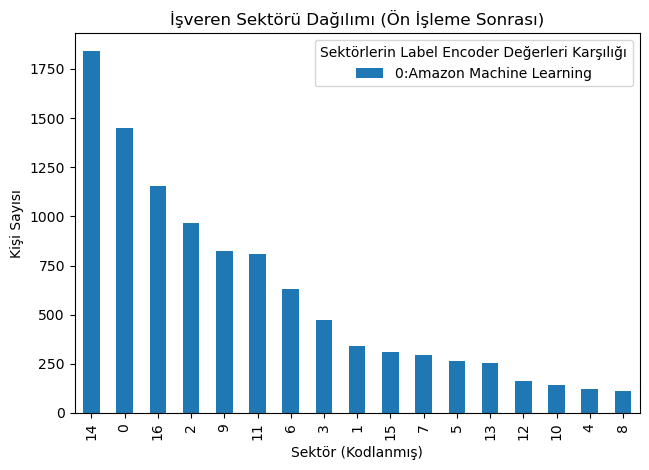

In [10]:
# İşveren Sektörü (EmployerIndustry) dağılımı - Bar Chart (Ön İşleme Sonrası)
plt.figurefigsize=(10,6)
df['EmployerIndustry'].value_counts().plot(kind='bar') 
plt.title('İşveren Sektörü Dağılımı (Ön İşleme Sonrası)')
plt.legend([f"{i}:{isim}"for i,isim in enumerate(label_encoder.classes_)],title="Sektörlerin Label Encoder Değerleri Karşılığı",loc='upper right')
plt.tight_layout()
plt.xlabel('Sektör (Kodlanmış)')
plt.ylabel('Kişi Sayısı')
plt.show()



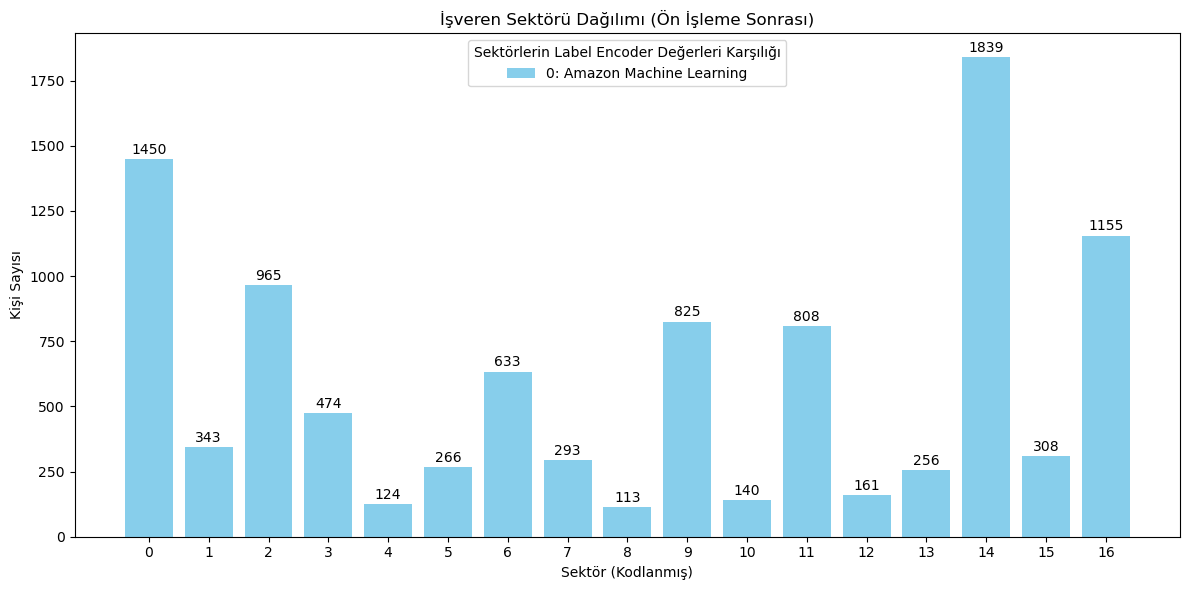

In [15]:


# Veri hazırlama
sektor_sayilari = df['EmployerIndustry'].value_counts().sort_index()

# Grafik çizimi
plt.figure(figsize=(12,6))
bars = plt.bar(sektor_sayilari.index, sektor_sayilari.values, color='skyblue')

plt.title('İşveren Sektörü Dağılımı (Ön İşleme Sonrası)')
plt.xlabel('Sektör (Kodlanmış)')
plt.ylabel('Kişi Sayısı')
plt.xticks(sektor_sayilari.index)

# Üstüne kişi sayılarını yaz
for i, v in enumerate(sektor_sayilari.values):
    plt.text(sektor_sayilari.index[i], v + 20, str(v), ha='center')

# Legend
etiketler = [f"{i}: {isim}" for i, isim in enumerate(label_encoder.classes_)]
plt.legend(etiketler, title="Sektörlerin Label Encoder Değerleri Karşılığı", loc="upper center")

plt.tight_layout()
plt.show()


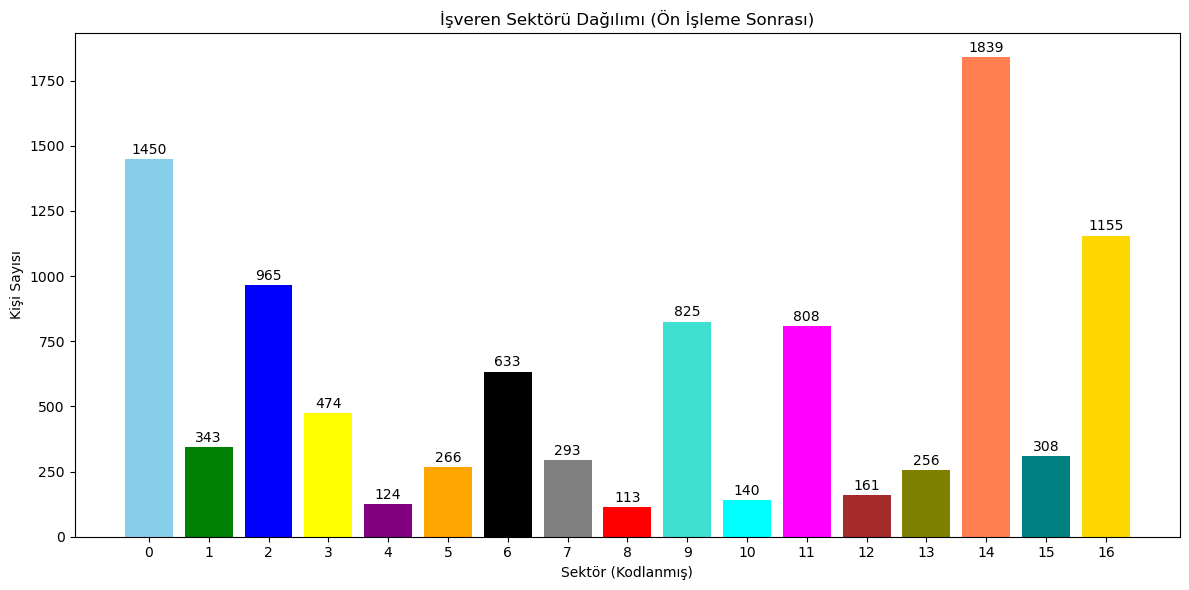

In [17]:

# Önce sektör sayılarını al
sektor_sayilari = df['EmployerIndustry'].value_counts().sort_index()

# Sadece kullanılan sektör kodlarını çekelim
kullanilan_kodlar = sektor_sayilari.index

# Kullanılan kodların isimlerini LabelEncoder'dan alalım
etiketler = [f"{kod}: {label_encoder.classes_[kod]}" for kod in kullanilan_kodlar]
 
# Grafik çizelim
plt.figure(figsize=(12,6))
bars = plt.bar(kullanilan_kodlar, sektor_sayilari.values, color=['skyblue','green','blue','yellow','purple','orange','black','gray','red','turquoise','cyan','magenta','brown','olive','coral','teal','gold'])

plt.title('İşveren Sektörü Dağılımı (Ön İşleme Sonrası)')
plt.xlabel('Sektör (Kodlanmış)')
plt.ylabel('Kişi Sayısı')
plt.xticks(kullanilan_kodlar)

# Barların üstüne kişi sayısı yazalım
for i, v in enumerate(sektor_sayilari.values):
    plt.text(kullanilan_kodlar[i], v + 20, str(v), ha='center')



plt.tight_layout()
plt.show()


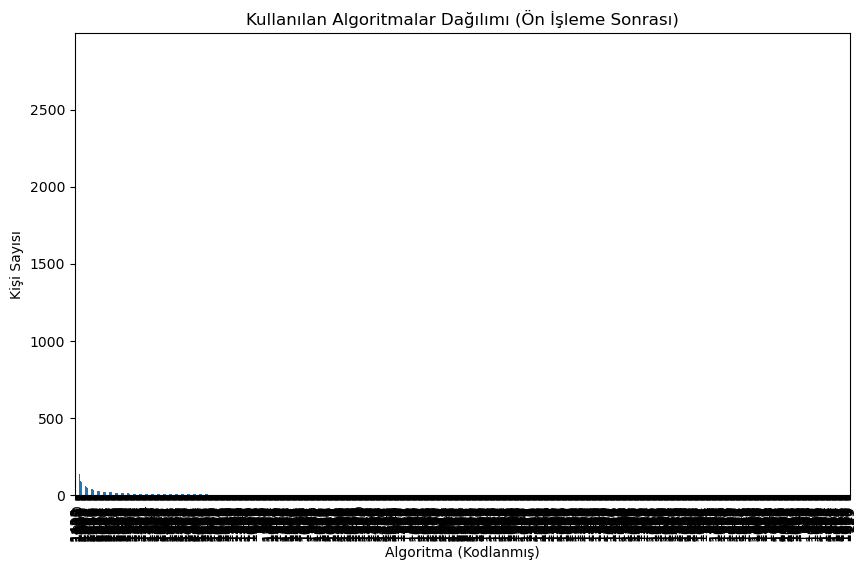

In [19]:
# Algoritmalar (WorkAlgorithmsSelect) dağılımı - Bar Chart (Ön İşleme Sonrası)
plt.figure(figsize=(10,6))
df['WorkAlgorithmsSelect'].value_counts().plot(kind='bar')
plt.title('Kullanılan Algoritmalar Dağılımı (Ön İşleme Sonrası)')
plt.xlabel('Algoritma (Kodlanmış)')
plt.ylabel('Kişi Sayısı')
plt.show()

In [20]:
# Özellikler (X) ve hedef değişken (y) belirleyelim
X = df[['WorkToolsSelect', 'LanguageRecommendationSelect', 'WorkAlgorithmsSelect']]
y = df['EmployerIndustry']


In [21]:
# Eğitim ve test verisine ayıralım
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.34, random_state=42)

In [22]:
# Modelleri oluştur
models = {
    "Decision Tree": DecisionTreeClassifier(),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier()
}

In [23]:
# Modellerin başarı skorlarını burada saklayacağız
scores = {}

In [24]:
# Her modeli eğit ve test et
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    scores[name] = acc
    print(f"{name} Doğruluk Oranı: {acc*100:.2f}%")
    ortalama_dogruluk=np.mean(list(scores.values()))
    print(f"Tüm Modellerin Ortalama Doğruluk Oranı:{ortalama_dogruluk*100:.2f}%")

Decision Tree Doğruluk Oranı: 22.50%
Tüm Modellerin Ortalama Doğruluk Oranı:22.50%
Naive Bayes Doğruluk Oranı: 27.08%
Tüm Modellerin Ortalama Doğruluk Oranı:24.79%
KNN Doğruluk Oranı: 24.93%
Tüm Modellerin Ortalama Doğruluk Oranı:24.84%
Random Forest Doğruluk Oranı: 22.94%
Tüm Modellerin Ortalama Doğruluk Oranı:24.36%


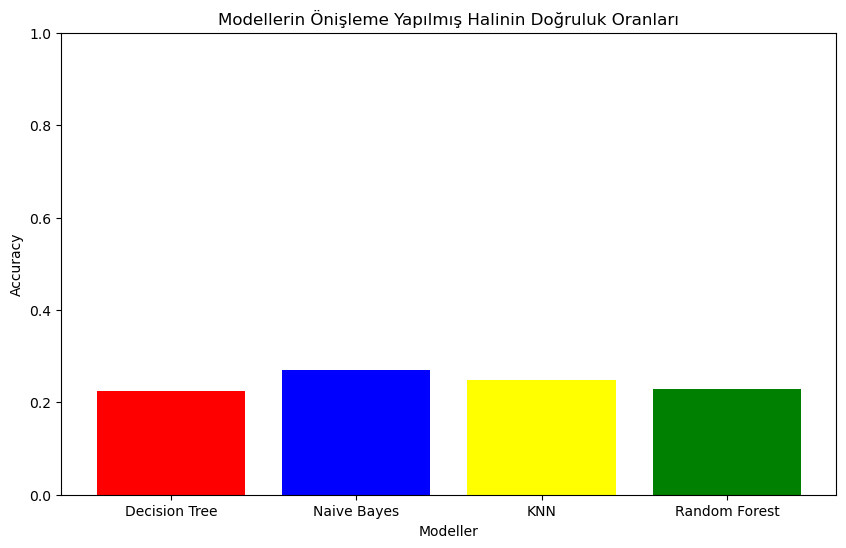

In [31]:
# Sonuçları bar grafiği olarak çizelim
plt.figure(figsize=(10,6))
plt.bar(scores.keys(), scores.values(), color=['red','blue','yellow','green'])
plt.title("Modellerin Önişleme Yapılmış Halinin Doğruluk Oranları")
plt.ylabel("Accuracy")
plt.xlabel("Modeller")
plt.ylim(0, 1)
plt.show()

In [33]:
# Farklı k değerleri
k_values = [1, 11, 13, 17, 21,30,40,80,120,200,225]
accuracy_scores = []

# Her k için modeli kur ve test et
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracy_scores.append(acc)
    print(f"k={k} için doğruluk: {acc*100:.3f}%")

k=1 için doğruluk: 21.604%
k=11 için doğruluk: 25.311%
k=13 için doğruluk: 25.195%
k=17 için doğruluk: 26.151%
k=21 için doğruluk: 27.049%
k=30 için doğruluk: 27.252%
k=40 için doğruluk: 27.512%
k=80 için doğruluk: 27.686%
k=120 için doğruluk: 28.034%
k=200 için doğruluk: 28.034%
k=225 için doğruluk: 28.323%


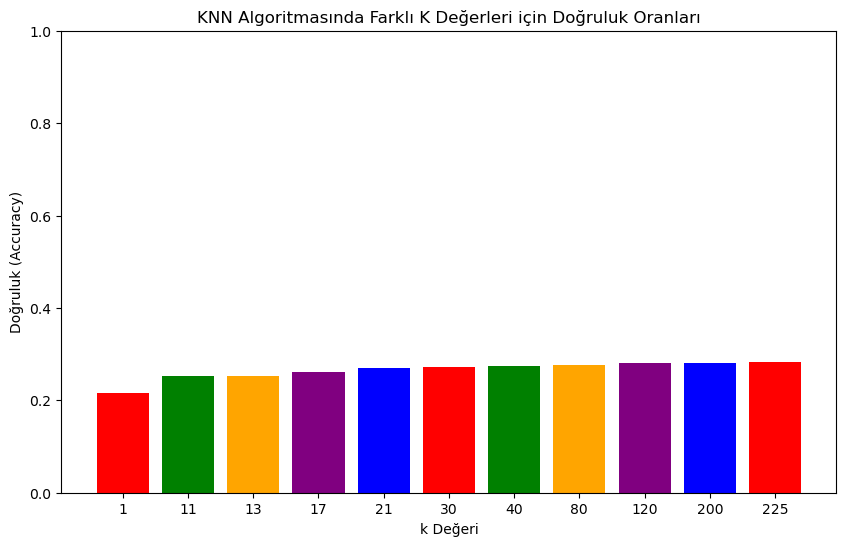

In [34]:
# Bar grafiğini çizelim
plt.figure(figsize=(10,6))
plt.bar([str(k) for k in k_values], accuracy_scores, color=['red','green','orange','purple','blue'])
plt.title("KNN Algoritmasında Farklı K Değerleri için Doğruluk Oranları")
plt.xlabel("k Değeri")
plt.ylabel("Doğruluk (Accuracy)")
plt.ylim(0,1)
plt.show()

In [35]:
# %66 eğitim ve %34 test ayrımı
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.34, random_state=42)

In [39]:
# --- MODELLER ---

# 1. Decision Tree
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

In [41]:
# Naive Bayes modelini kur
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)


In [43]:
# 2. Random Forest
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

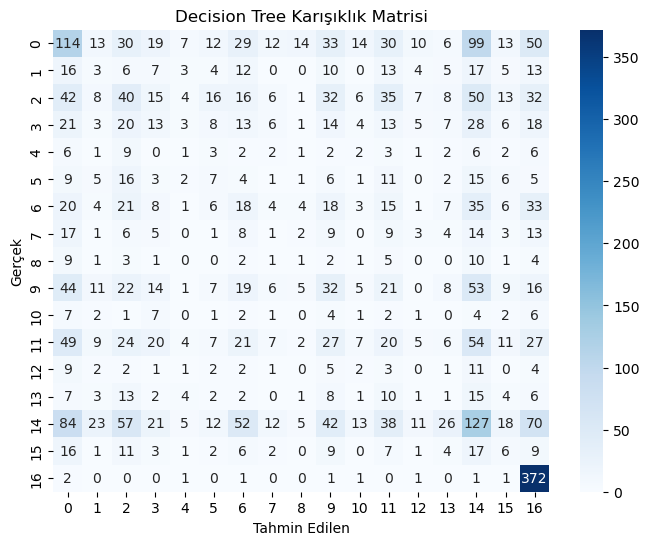

In [44]:
# --- KARMAŞIKLIK MATRİSLERİNİ OLUŞTURALIM ---

# 1. Decision Tree Karışıklık Matrisi
cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(8,6))
sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Blues")
plt.title("Decision Tree Karışıklık Matrisi")
plt.xlabel("Tahmin Edilen")
plt.ylabel("Gerçek")
plt.show()

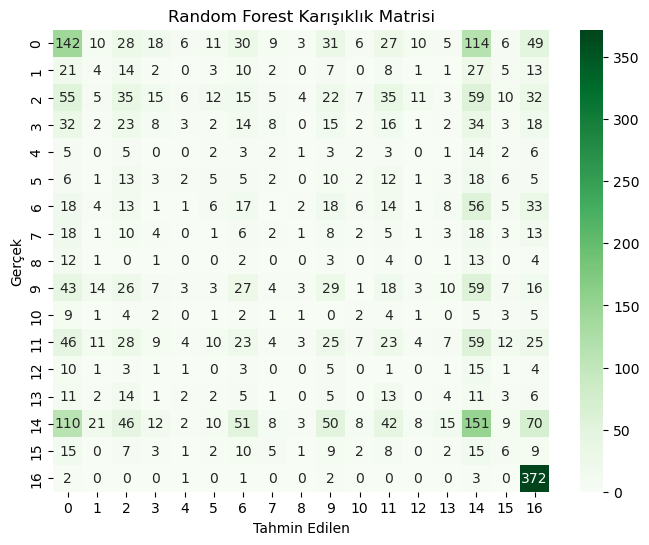

In [45]:
# 2. Random Forest Karışıklık Matrisi
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8,6))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens")
plt.title("Random Forest Karışıklık Matrisi")
plt.xlabel("Tahmin Edilen")
plt.ylabel("Gerçek")
plt.show()

In [46]:
# %66 eğitim ve %34 test ayrımı
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.34, random_state=42)

In [48]:
# k=1 için Karışıklılık Matrisi KNN
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

    

In [49]:
cm = confusion_matrix(y_test, y_pred)

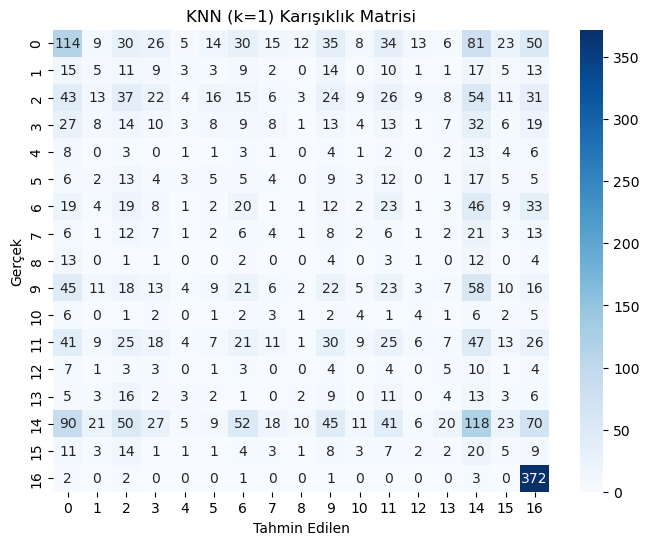

In [50]:
# Isı haritası çizelim
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"KNN (k=1) Karışıklık Matrisi")
plt.xlabel("Tahmin Edilen")
plt.ylabel("Gerçek")
plt.show()


In [52]:
# k=11 için Karışıklılık Matrisi KNN
knn = KNeighborsClassifier(n_neighbors=11)    
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)         
    

In [53]:
cm = confusion_matrix(y_test, y_pred)

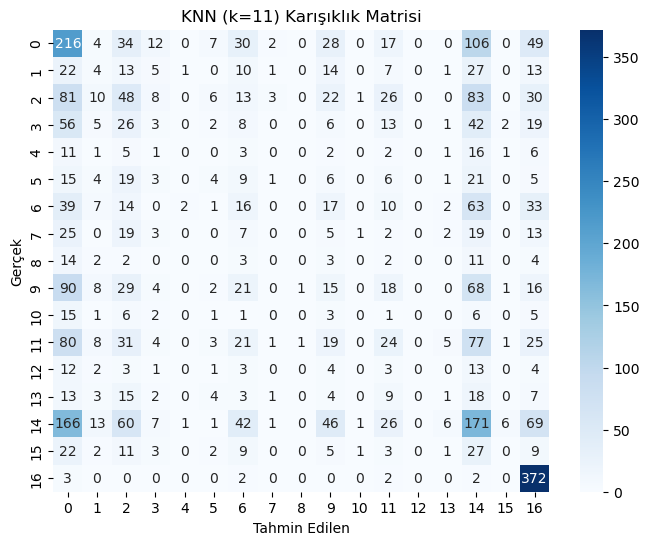

In [54]:
# Isı haritası çizelim
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"KNN (k=11) Karışıklık Matrisi")
plt.xlabel("Tahmin Edilen")
plt.ylabel("Gerçek")
plt.show()
    

In [57]:
# k=13 için Karışıklılık Matrisi KNN
knn = KNeighborsClassifier(n_neighbors=13)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
      
   

In [60]:
cm = confusion_matrix(y_test, y_pred)

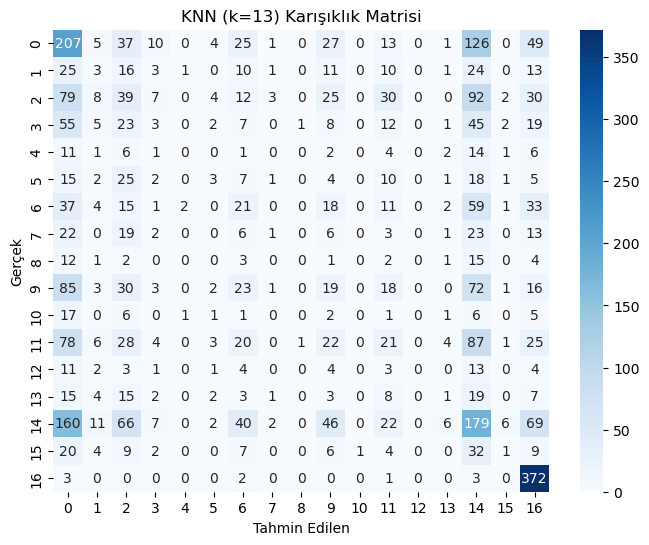

In [61]:
# Isı haritası çizelim
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"KNN (k=13) Karışıklık Matrisi")
plt.xlabel("Tahmin Edilen")
plt.ylabel("Gerçek")
plt.show()
   

In [62]:
# k=17 için Karışıklılık Matrisi KNN
knn = KNeighborsClassifier(n_neighbors=17)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
         
    

In [64]:
cm = confusion_matrix(y_test, y_pred)

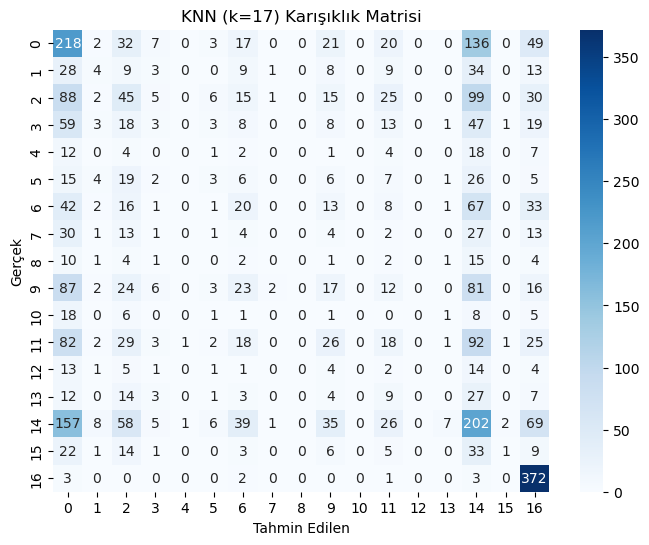

In [67]:
 # Isı haritası çizelim
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"KNN (k=17) Karışıklık Matrisi")
plt.xlabel("Tahmin Edilen")
plt.ylabel("Gerçek")
plt.show()

In [68]:
# k=21 için Karışıklılık Matrisi KNN
knn = KNeighborsClassifier(n_neighbors=21)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
 
    

In [69]:
cm = confusion_matrix(y_test, y_pred)

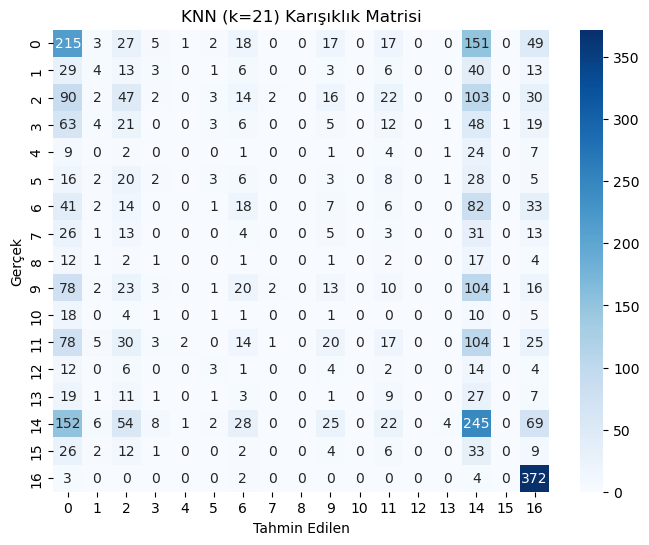

In [70]:
# Isı haritası çizelim
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"KNN (k=21) Karışıklık Matrisi")
plt.xlabel("Tahmin Edilen")
plt.ylabel("Gerçek")
plt.show()

In [72]:
# Karışıklık Matrisi
cm_nb = confusion_matrix(y_test, y_pred_nb)

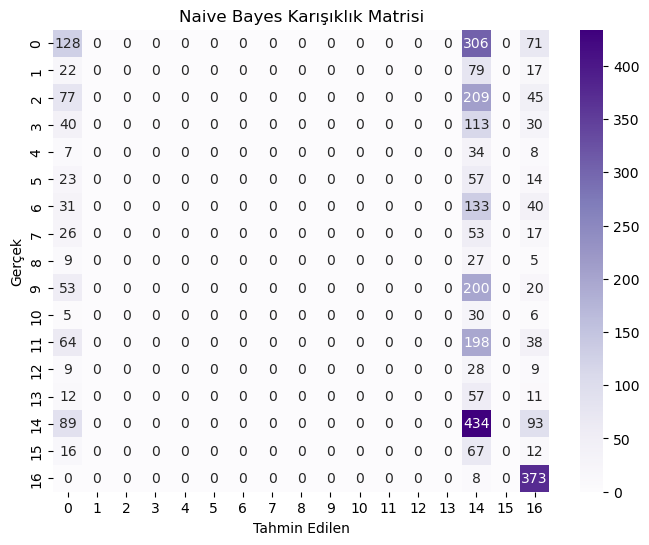

In [75]:
# Isı haritası çizelim
plt.figure(figsize=(8,6))
sns.heatmap(cm_nb, annot=True, fmt="d", cmap="Purples")
plt.title("Naive Bayes Karışıklık Matrisi")
plt.xlabel("Tahmin Edilen")
plt.ylabel("Gerçek")
plt.show()

# --- 10-Fold Çapraz Doğrulama ---

In [77]:
# Decision Tree için
dt_model = DecisionTreeClassifier()
dt_scores = cross_val_score(dt_model, X, y, cv=10)
ortalama=dt_scores.mean()
print("Decision Tree 10-Fold Ortalama Doğruluk:{:.2f}%".format(ortalama*100))


Decision Tree 10-Fold Ortalama Doğruluk:21.69%


In [78]:
# Random Forest için
rf_model = RandomForestClassifier()
rf_scores = cross_val_score(rf_model, X, y, cv=10)
ortalama=rf_scores.mean()
print("Random Forest 10-Fold Ortalama Doğruluk:{:.2f}%".format(ortalama*100))

Random Forest 10-Fold Ortalama Doğruluk:23.15%


In [81]:
# KNN farklı k değerleri için
k_values = [1, 11, 13, 17, 21,30,40,80,120,200,225]
for k in k_values:
    knn_model = KNeighborsClassifier(n_neighbors=k)
    knn_scores = cross_val_score(knn_model, X, y, cv=10)
    ortalama=knn_scores.mean()
    print("KNN (k={}) 10-Fold Ortalama Doğruluk:{:.2f}%".format(k,ortalama*100))

KNN (k=1) 10-Fold Ortalama Doğruluk:11.49%
KNN (k=11) 10-Fold Ortalama Doğruluk:24.68%
KNN (k=13) 10-Fold Ortalama Doğruluk:25.16%
KNN (k=17) 10-Fold Ortalama Doğruluk:25.74%
KNN (k=21) 10-Fold Ortalama Doğruluk:26.64%
KNN (k=30) 10-Fold Ortalama Doğruluk:26.98%
KNN (k=40) 10-Fold Ortalama Doğruluk:27.51%
KNN (k=80) 10-Fold Ortalama Doğruluk:27.61%
KNN (k=120) 10-Fold Ortalama Doğruluk:28.40%
KNN (k=200) 10-Fold Ortalama Doğruluk:28.65%
KNN (k=225) 10-Fold Ortalama Doğruluk:28.68%


In [83]:
# Naive Bayes Modeli
nb_model = GaussianNB()
nb_scores = cross_val_score(nb_model, X, y, cv=10)
ortalama=nb_scores.mean()
print("Naive Bayes 10-Fold Ortalama Doğruluk:{:.2f}%".format (ortalama*100))

Naive Bayes 10-Fold Ortalama Doğruluk:27.02%


In [85]:
from sklearn.model_selection import train_test_split

# Özellik ve hedef değişken
X = df.drop("EmployerIndustry", axis=1)
y = df["EmployerIndustry"]

# Eğitim ve test verisine ayır
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.34, random_state=42)


In [88]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def print_score(model, X_train, y_train, X_test, y_test, train=True):
    if train:
        pred = model.predict(X_train)
        print("📘 [Eğitim Verisi ile Tahmin Sonuçları]")
        print("Accuracy (Doğruluk): {:.2f}%".format(accuracy_score(y_train, pred) * 100))
        print("Precision (Kesinlik): {:.2f}%".format(precision_score(y_train, pred, average='macro') * 100))
        print("Recall (Duyarlılık): {:.2f}%".format(recall_score(y_train, pred, average='macro') * 100))
        print("F1 Score: {:.2f}%".format(f1_score(y_train, pred, average='macro') * 100))
        print("Confusion Matrix:\n", confusion_matrix(y_train, pred))
    else:
        pred = model.predict(X_test)
        print("🧪 [Test Verisi ile Tahmin Sonuçları]")
        print("Accuracy (Doğruluk): {:.2f}%".format(accuracy_score(y_test, pred) * 100))
        print("Precision (Kesinlik): {:.2f}%".format(precision_score(y_test, pred, average='macro') * 100))
        print("Recall (Duyarlılık): {:.2f}%".format(recall_score(y_test, pred, average='macro') * 100))
        print("F1 Score: {:.2f}%".format(f1_score(y_test, pred, average='macro') * 100))
        print("Confusion Matrix:\n", confusion_matrix(y_test, pred))



In [89]:
# Random Forest Sınıflandırması
from sklearn.ensemble import RandomForestClassifier

rf_clf=RandomForestClassifier(n_estimators=100,random_state=42)
rf_clf.fit(X_train,y_train)

# Sonuçları Yazdıralım
print_score(rf_clf,X_train,y_train,X_test,y_test,train=True)
print_score(rf_clf,X_train,y_train,X_test,y_test,train=False)

📘 [Eğitim Verisi ile Tahmin Sonuçları]
Accuracy (Doğruluk): 88.15%
Precision (Kesinlik): 94.81%
Recall (Duyarlılık): 86.67%
F1 Score: 90.02%
Confusion Matrix:
 [[ 826    0    5    0    0    0    0    0    0    3    0    2    0    0
    10    1   98]
 [   4  189    0    0    1    0    0    0    0    1    0    1    0    0
     0    0   29]
 [   7    1  548    1    0    0    0    0    0    3    0    3    2    0
     9    0   60]
 [   8    1    1  243    1    0    0    0    2    2    0    1    0    2
     5    1   24]
 [   0    0    0    0   57    1    1    0    0    0    0    0    0    0
     0    0   16]
 [   2    0    1    0    0  152    0    0    0    0    0    0    0    0
     0    0   17]
 [   4    0    0    0    0    1  381    1    0    2    0    1    0    0
     6    0   33]
 [   5    1    1    1    0    0    0  165    0    2    0    1    0    0
     2    0   19]
 [   0    0    0    0    0    0    0    0   63    2    0    0    0    0
     1    0    6]
 [   5    1    1    0    0    

In [92]:
dt_model = DecisionTreeClassifier()

In [93]:
dt_model.fit(X_train, y_train)

DecisionTreeClassifier()

In [ ]:
# Karar Ağacı Görseli
from IPython.display import Image
from six import StringIO
from sklearn.tree import export_graphviz
import pydot

features = list(X.columns)
dot_data = StringIO()
export_graphviz(dt_model, out_file=dot_data, feature_names=features, filled=True)
graph = pydot.graph_from_dot_data(dot_data.getvalue())
Image(graph[0].create_png())

In [ ]:
# 13. Random Forest İçinden Tek Bir Ağacı Görüselleştirme
estimator = rf_clf.estimators_[0]

dot_data_rf = StringIO()
export_graphviz(estimator, out_file=dot_data_rf, feature_names=features, filled=True, rounded=True, special_characters=True)
graph_rf = pydot.graph_from_dot_data(dot_data_rf.getvalue())
Image(graph_rf[0].create_png())

In [ ]:
# 14. Random Forest Özellik Önemi Grafiği
importances = rf_clf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,10))
sns.barplot(x=importances[indices], y=X.columns[indices])
plt.title('Random Forest - Özellik Önem Dereceleri')
plt.xlabel('Önem Skoru')
plt.ylabel('Özellikler')
plt.show()

# Yapay Zeka Modeli Kişinin Kullanışmış olduğu İş Araçlarına,Programlama Dillerine ve Algoritmalara Göre Bir Çıkarım Bulunmak =)

In [ ]:
# Gerekli kütüphaneleri yükleyelim
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow import keras

# Veri setini oku
df = pd.read_csv('kagglesurvey.csv')

# 1. Adım: Gereksiz sütunu at
df = df.drop(columns=["Respondent"])

# 2. Adım: Eksik verileri 'Bilinmiyor' ile doldur
df = df.fillna('Bilinmiyor')

# 3. Adım: Kategorik verileri sayısallaştır
label_encoders = {}
for column in df.columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le

# 4. Adım: Özellikler ve etiket ayırımı
X = df.drop(columns=["EmployerIndustry"])  # Özellikler
y = df["EmployerIndustry"]                 # Etiket

# 5. Adım: Eğitim ve test seti bölmesi
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Adım: Yapay Sinir Ağı (ANN) Modeli
model = keras.Sequential([
    keras.layers.Dense(64, input_shape=(X_train.shape[1],), activation='relu'),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(len(y.unique()), activation='softmax')  # Çok sınıflı çıktı için softmax
])

# 7. Adım: Modeli derle
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 8. Adım: Modeli eğit
history = model.fit(X_train, y_train, epochs=30, batch_size=32, validation_split=0.2)

# 9. Adım: Test seti üzerinde değerlendir
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print(f"Test Loss: {test_loss*100}%")
print(f"Test Accuracy: {test_accuracy*100}%")
